In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import copy
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Rectangle

In [5]:
Diffusion_attributes = pd.read_excel("Diffusion_attributes_new.xlsx")
Diffusion_attributes

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
0,16,0.5,0.50,1.5,558,40.61,957,399,1.741680,62.433165
1,14,0.5,0.50,1.5,587,33.88,1128,541,1.741680,62.433165
2,12,0.5,0.50,1.5,750,37.34,1284,534,1.741680,62.433165
3,10,0.5,0.50,1.5,878,33.00,1834,956,1.741680,62.433165
4,8,0.5,0.50,1.5,1045,25.65,2038,993,1.741680,62.433165
5,6,0.4,0.50,1.5,2669,42.97,3900,1231,1.154318,52.265323
6,6,0.3,0.50,1.5,3718,38.70,7094,3376,0.763499,41.906204
7,6,0.6,0.50,1.5,963,28.58,1700,737,2.619991,71.611570
8,6,0.7,0.50,1.5,694,33.90,1494,800,3.923540,78.894036
9,6,0.8,0.50,1.5,466,30.72,1104,638,5.836782,85.319400


In [7]:
index_to_drop = [26,27,28,29,30]
Diffusion_attributes=Diffusion_attributes.drop(index_to_drop)
Diffusion_attributes

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
0,16,0.5,0.5,1.5,558,40.61,957,399,1.741680,62.433165
1,14,0.5,0.5,1.5,587,33.88,1128,541,1.741680,62.433165
2,12,0.5,0.5,1.5,750,37.34,1284,534,1.741680,62.433165
3,10,0.5,0.5,1.5,878,33.00,1834,956,1.741680,62.433165
4,8,0.5,0.5,1.5,1045,25.65,2038,993,1.741680,62.433165
5,6,0.4,0.5,1.5,2669,42.97,3900,1231,1.154318,52.265323
6,6,0.3,0.5,1.5,3718,38.70,7094,3376,0.763499,41.906204
7,6,0.6,0.5,1.5,963,28.58,1700,737,2.619991,71.611570
8,6,0.7,0.5,1.5,694,33.90,1494,800,3.923540,78.894036
9,6,0.8,0.5,1.5,466,30.72,1104,638,5.836782,85.319400


In [11]:
Diffusion_attributes_price=Diffusion_attributes.iloc[[12,13,14,15,16,17,18]]
Diffusion_attributes_rewire=Diffusion_attributes.iloc[[5,6,7,8,9,10,11,13]]
Diffusion_attributes_ties=Diffusion_attributes.iloc[[0,1,2,3,4,13,26]]
Diffusion_attributes_belonging=Diffusion_attributes.iloc[[13,19,20,21,22,23,24,25]]

/var/folders/jn/0xk4zl4s6bz_ns00xx5z3b4r0000gn/T/ipykernel_1981/699625922.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  colorbar_ties.ax.set_xticklabels(colorbar_ties.get_ticks(), fontsize=8, color='red')


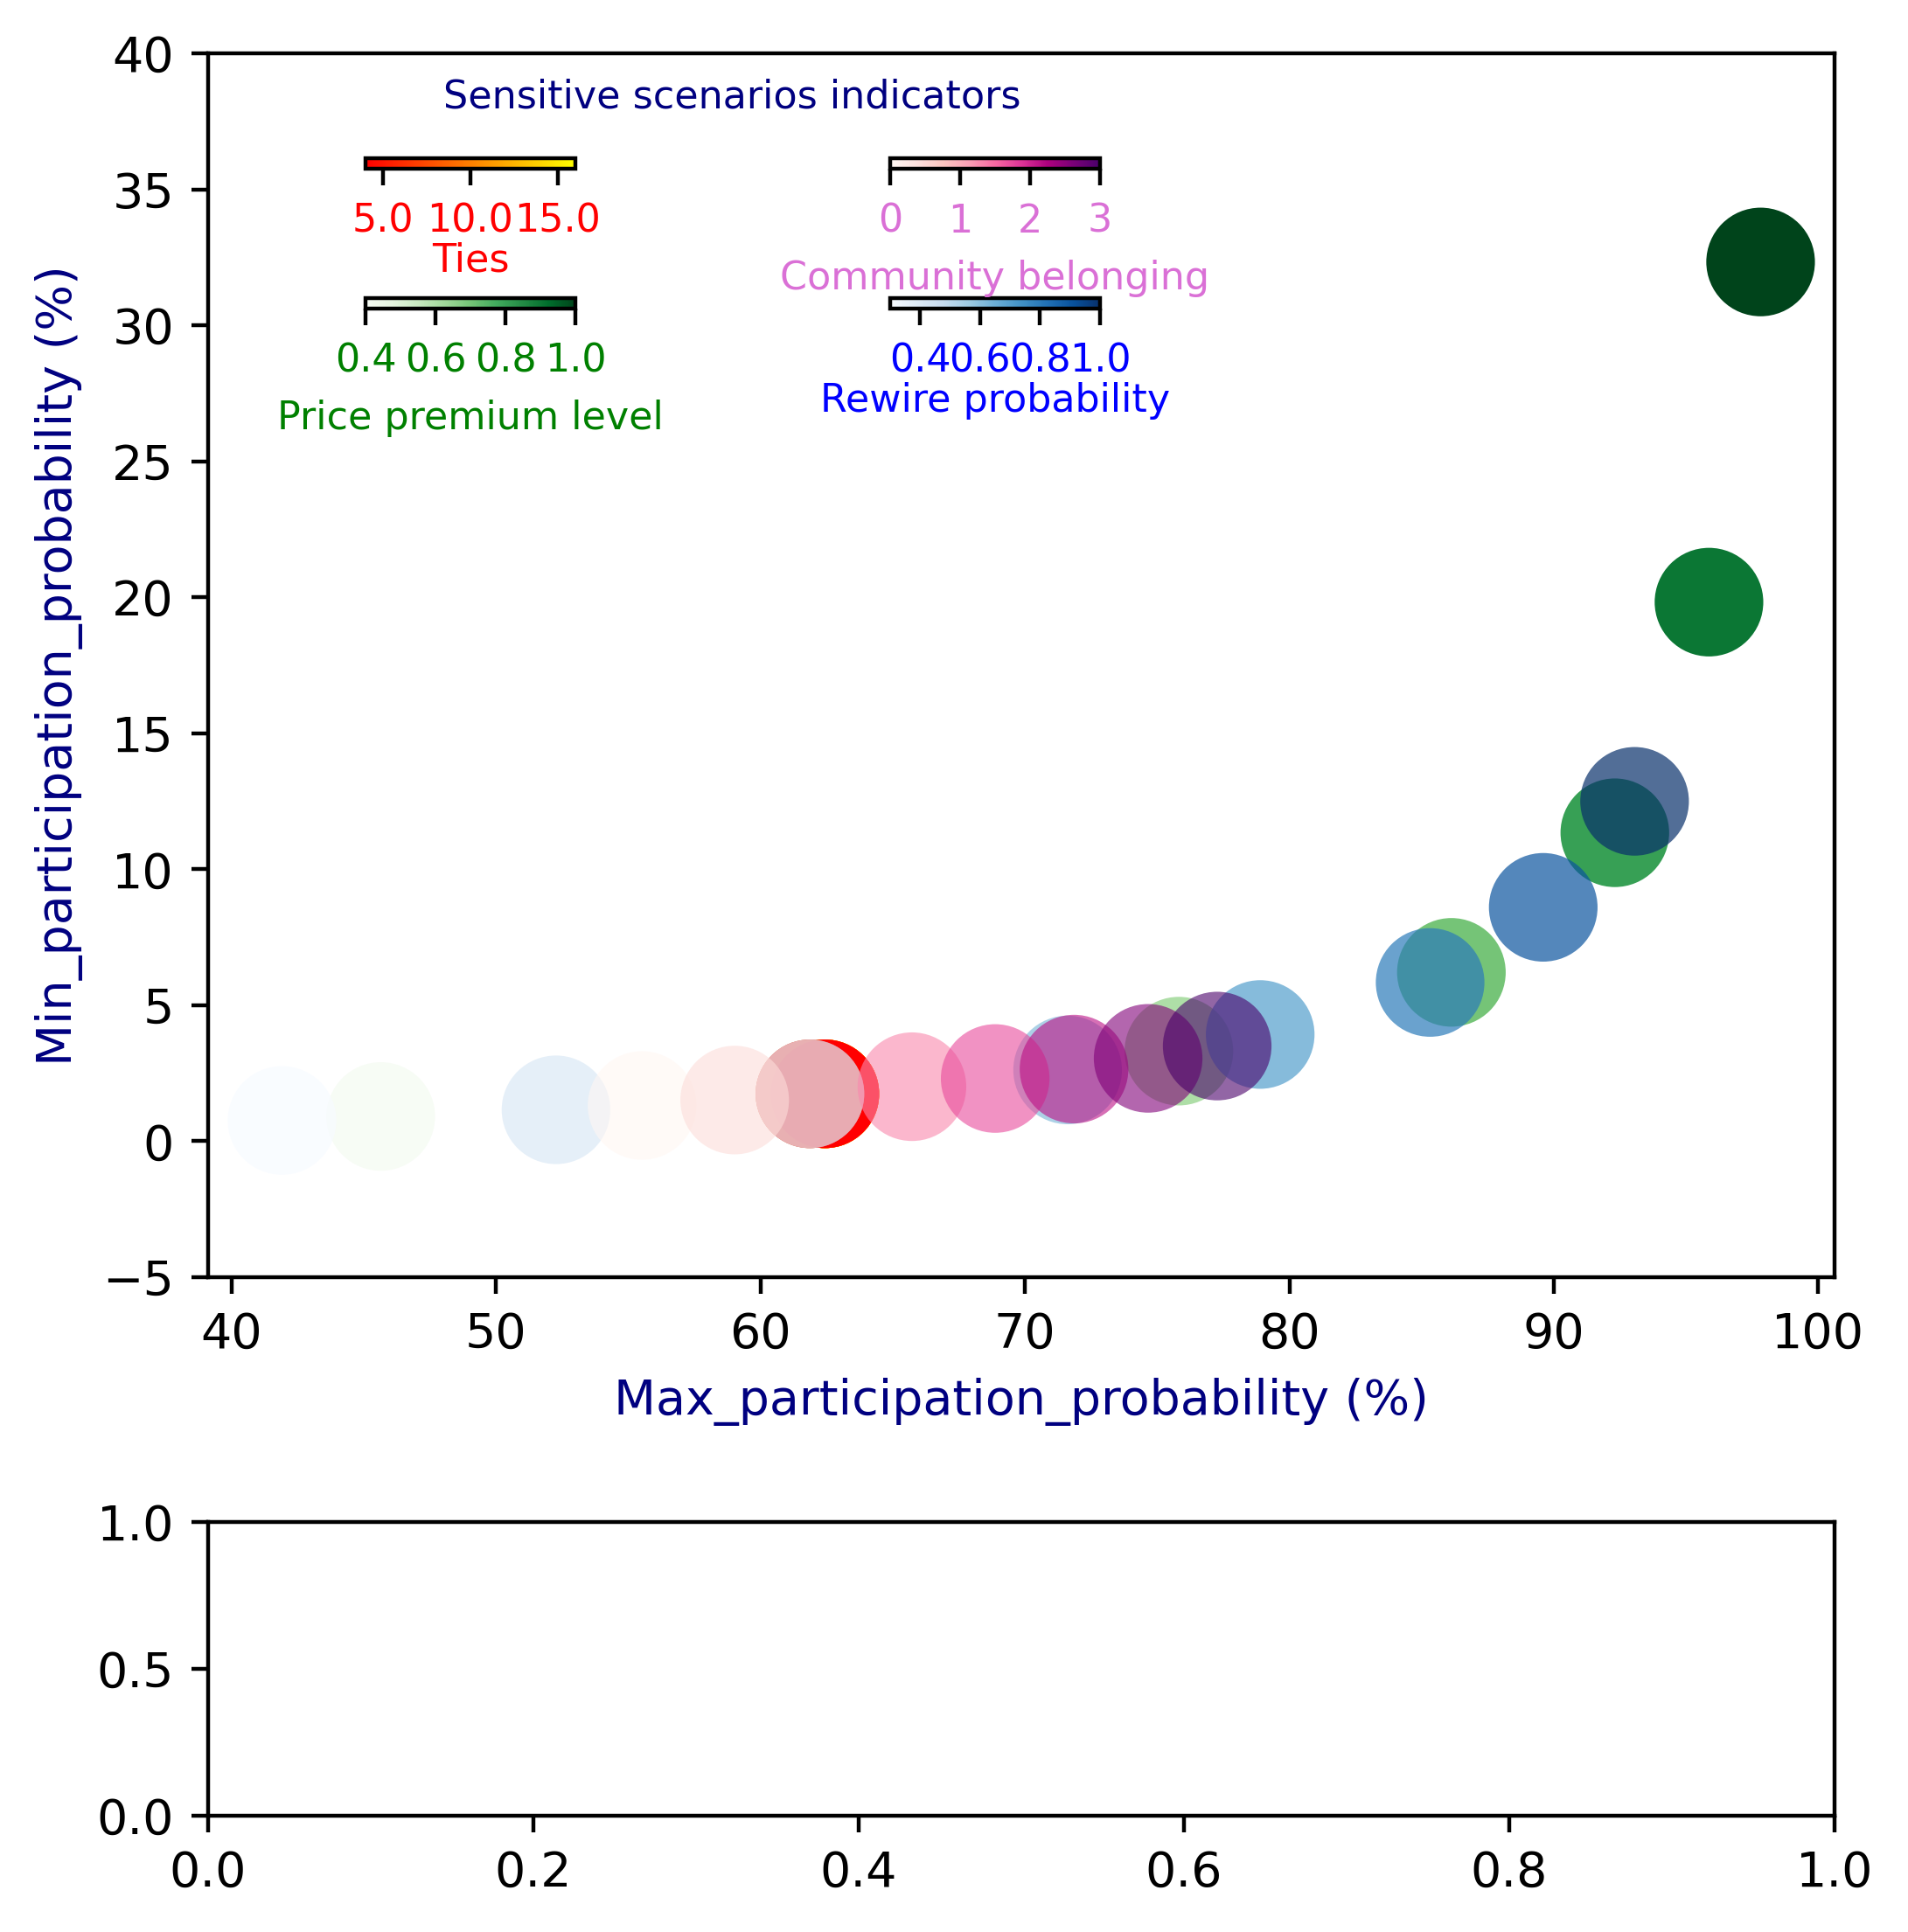

In [13]:
x_scatter_price = Diffusion_attributes_price['max_probability']
y_scatter_price = Diffusion_attributes_price['min_probability']
x_scatter_ties = Diffusion_attributes_ties['max_probability']
y_scatter_ties = Diffusion_attributes_ties['min_probability']
x_scatter_rewire = Diffusion_attributes_rewire['max_probability']
y_scatter_rewire = Diffusion_attributes_rewire['min_probability']
x_scatter_belonging = Diffusion_attributes_belonging['max_probability']
y_scatter_belonging = Diffusion_attributes_belonging['min_probability']
fig, (ax1, ax2) = plt.subplots(2, figsize=(6,10),dpi=400)

fig_scatter=ax1.scatter(x_scatter_price,y_scatter_price,c=Diffusion_attributes_price['Price_increasement'], cmap='Greens',s=500, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_ties,y_scatter_ties,c=Diffusion_attributes_ties['Average_ties'], cmap='autumn',s=500, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_rewire,y_scatter_rewire,c=Diffusion_attributes_rewire['Rewire_probability'], cmap='Blues',s=500, alpha=0.7, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_belonging,y_scatter_belonging,c=Diffusion_attributes_belonging['Community_belonging'], cmap='RdPu',s=500, alpha=0.6, edgecolors='none')

cmap_ties = 'autumn'
norm_ties = mcolors.Normalize(min(Diffusion_attributes['Average_ties']),max(Diffusion_attributes['Average_ties']))


cmap_interaction = 'Blues'
norm_interaction = mcolors.Normalize(min(Diffusion_attributes['Rewire_probability']),max(Diffusion_attributes['Rewire_probability']))


cmap_price = 'Greens'
norm_price = mcolors.Normalize(min(Diffusion_attributes['Price_increasement']),max(Diffusion_attributes['Price_increasement']))

    
cmap_belonging = 'RdPu'
norm_belonging = mcolors.Normalize(0,3)


sm_ties = ScalarMappable(cmap=cmap_ties, norm=norm_ties)
sm_ties.set_array([])
colorbar_ties=fig.colorbar(sm_ties, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_ties.ax.set_position([0.2,0.75,0.1,0.1])
#colorbar_ties.ax.set_xticks([6,8,10,12,14,16])
colorbar_ties.ax.set_xticklabels(colorbar_ties.get_ticks(), fontsize=8, color='red')
colorbar_ties.set_label('Ties', rotation=-360, labelpad=0.35, fontsize=8, color='red')

sm_interaction = ScalarMappable(cmap=cmap_interaction, norm=norm_interaction)
sm_interaction.set_array([])
colorbar_interaction=fig.colorbar(sm_interaction, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_interaction.ax.set_position([0.45,0.71,0.1,0.1])
colorbar_interaction.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_interaction.ax.set_xticklabels(colorbar_interaction.get_ticks(), fontsize=8, color='blue')
colorbar_interaction.set_label('Rewire probability', rotation=-360, labelpad=0.35, fontsize=8, color='blue')


sm_price = ScalarMappable(cmap=cmap_price, norm=norm_price)
sm_price.set_array([])
colorbar_price=fig.colorbar(sm_price, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_price.ax.set_position([0.2,0.71,0.1,0.1])
colorbar_price.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_price.ax.set_xticklabels(colorbar_price.get_ticks(), fontsize=8, color='green')
colorbar_price.set_label('Price premium level', rotation=0, fontsize=8, color='green')

sm_belonging = ScalarMappable(cmap=cmap_belonging, norm=norm_belonging)
sm_belonging.set_array([])
colorbar_belonging=fig.colorbar(sm_belonging, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_belonging.ax.set_position([0.45,0.75,0.1,0.1])
colorbar_belonging.ax.set_xticks([0,1,2,3])
colorbar_belonging.ax.set_xticklabels(colorbar_belonging.get_ticks(), fontsize=8, color='orchid')
colorbar_belonging.set_label('Community belonging', rotation=0, fontsize=8, color='orchid')

#ax2.axis('off')
ax1.text(48, 38, 'Sensitive scenarios indicators', fontsize=8, color='navy')

ax1.set_xlabel('Max_participation_probability (%)', color='navy')
ax1.set_ylabel('Min_participation_probability (%)', color='navy')
ax1.set_ylim(-5,40)

plt.savefig('max_min_proportion2.jpg')
plt.show()

In [153]:
Diffusion_attributes.to_excel('Diffusion_attributes.xlsx',index=False)